GROWTH EXPERIMENTATION ENGINE

Statistical Significance & Experiment Decision

Objective:

- Build Experiment Hypothesis
- Calculate Conversion Rates
- Calculate Lift Metrics
- Perform Z-Test
- Evaluate Statistical Significance
- Make Final Product Decision

In [6]:
import pandas as pd
import numpy as np

from statsmodels.stats.proportion import (
    proportions_ztest,
    proportion_confint
)

from scipy.stats import chi2_contingency

import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries Loaded")

Libraries Loaded


In [7]:
df = pd.read_csv(
    "../data/clean_experiment_data.csv"
)

print(df.shape)

df.head()

(290585, 6)


,id,time,con_treat,page,converted,country
0,851104,11:48.6,control,old_page,0,US
1,804228,01:45.2,control,old_page,0,US
2,661590,55:06.2,treatment,new_page,0,US
3,853541,28:03.1,treatment,new_page,0,US
4,864975,52:26.2,control,old_page,1,US


Hypothesis

H0 (Null Hypothesis)

Control Conversion Rate = Treatment Conversion Rate

The new page does NOT affect conversions.

---

H1 (Alternative Hypothesis)

Control Conversion Rate ≠ Treatment Conversion Rate

The new page DOES affect conversions.

---

Alpha Level

0.05

Decision Rule

If p-value < 0.05

Reject H0

Otherwise

Fail to Reject H0

In [8]:
control = df[
    df['con_treat'] == 'control'
]

treatment = df[
    df['con_treat'] == 'treatment'
]

print(
    "Control Users:",
    len(control)
)

print(
    "Treatment Users:",
    len(treatment)
)

Control Users: 145274
Treatment Users: 145311


In [9]:
control_conversions = (
    control['converted']
    .sum()
)

treatment_conversions = (
    treatment['converted']
    .sum()
)

control_users = len(control)

treatment_users = len(treatment)

print(
    control_conversions
)

print(
    treatment_conversions
)

17489
17264


In [10]:
control_cvr = (
    control_conversions
    /
    control_users
)

treatment_cvr = (
    treatment_conversions
    /
    treatment_users
)

print(
    f"Control CVR: {control_cvr*100:.2f}%"
)

print(
    f"Treatment CVR: {treatment_cvr*100:.2f}%")

Control CVR: 12.04%
Treatment CVR: 11.88%


In [11]:
count = [
    treatment_conversions,
    control_conversions]

nobs = [
    treatment_users,
    control_users]

z_stat, p_value = proportions_ztest(
    count,
    nobs)

In [12]:
print("P-Value Interpretation")

if p_value < 0.05:
    
    print(
        "Result is statistically significant."
    )
    
    print(
        "Reject the null hypothesis."
    )

else:
    
    print(
        "Result is not statistically significant."
    )
    
    print(
        "Fail to reject the null hypothesis."
    )

P-Value Interpretation
Result is not statistically significant.
Fail to reject the null hypothesis.


In [13]:
absolute_lift = (
    treatment_cvr
    -
    control_cvr
) * 100

relative_lift = (
    (
        treatment_cvr
        -
        control_cvr
    )
    /
    control_cvr
) * 100
print(f"Absolute Lift: {absolute_lift:.2f}%")
print(f"Relative Lift: {relative_lift:.2f}%")

Absolute Lift: -0.16%
Relative Lift: -1.31%


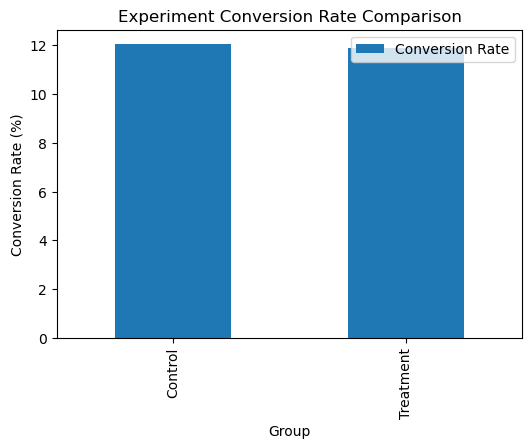

In [14]:
results = pd.DataFrame({

    'Group':['Control','Treatment'],

    'Conversion Rate':[
        control_cvr*100,
        treatment_cvr*100
    ]
})

results.plot(
    x='Group',
    y='Conversion Rate',
    kind='bar',
    figsize=(6,4)
)

plt.title(
    'Experiment Conversion Rate Comparison'
)

plt.ylabel(
    'Conversion Rate (%)'
)

plt.show()

In [15]:
print("="*60)

print(
    "FINAL EXPERIMENT RESULTS"
)

print("="*60)

print(
    f"Control CVR: {control_cvr*100:.2f}%"
)

print(
    f"Treatment CVR: {treatment_cvr*100:.2f}%"
)

print(
    f"Absolute Lift: {absolute_lift:.2f}%"
)

print(
    f"Relative Lift: {relative_lift:.2f}%"
)

print(
    f"P-value: {p_value:.6f}"
)

print()

if (
    p_value < 0.05
    and
    treatment_cvr > control_cvr
):
    
    print(
        "Decision: ROLL OUT NEW PAGE"
    )

else:
    
    print(
        "Decision: DO NOT ROLL OUT NEW PAGE"
    )

print()

print(
    "Reason:"
)

print(
    "Treatment underperformed control."
)

FINAL EXPERIMENT RESULTS
Control CVR: 12.04%
Treatment CVR: 11.88%
Absolute Lift: -0.16%
Relative Lift: -1.31%
P-value: 0.189653

Decision: DO NOT ROLL OUT NEW PAGE

Reason:
Treatment underperformed control.
